# 33. A PyTorch workflow example

1. Get data ready
    - Turn into tensors

2. Build or pick a pretrained model
    - To suit your problem
    2.1. Pick a loss function and optimiser
    2.2. Build a training loop

3. Fit the model to the data and make a prediction

4. Evaluate the model

5. Improve through experimentation

6. Save and reload your trained model

# 34. Getting Set Up

In [15]:
import torch
# nn contains all of PyTorch's building blocks for neural networks
from torch import nn 

# matplotlib is a plotting library for Python, used to create graphs and visualizations
# We'll use it to visualise our data and the results of our models
# Importing something as another name is called aliasing, here we're aliasing matplotlib.pyplot as plt
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.12.0+cpu'

# Creating A Data Set With Linear Regression

1. Data (preparing and loading)

Data can be almost anything in ML
- Excel Spreadsheet
- Images
- Videos
- Audio
- DNA
- Text

ML is a game of two parts
- Get data into a numerical representation
    - e.g. vectors, matrices, tensors
- Build a model to learn patterns in that numerical representation
    - Build NN to learn a representation/patterns/features/weights
    - Output that representation
    - Do something with that representation

2. Linear Regression

A linear regression line has an equation of the form y = mx + c
    - x is the independent variable
    - y is the dependent variable
- For multiple independent variables, the equation becomes y = beta_0 + beta_1 * x_1 + ... + beta_n * x_n

We will use a linear regression formula to make a straight line with known parameters here

In [16]:
# Create known parameters
weight = 0.7    # b
bias = 0.3      # a

# Create a range of values between 0 and 1, with a step of 0.02
start = 0
end = 1
step = 0.02

# torch.arange() creates a 1D tensor of values from start to end with the specified step size (here it is a row vector)
# unsqueeze(dim=1) adds an extra dimension to the tensor (here making it a column vector), making it a 2D tensor with shape (N rows, 1 columns), we do this because PyTorch models expect input data to be in a 2D format (batch_size, num_features)
# Capital X because it is a tensor, and tensors are often represented with uppercase letters in machine learning (vectors are often represented with lowercase letters)
X = torch.arange(start, end, step).unsqueeze(dim=1)
# Calculate the corresponding y values using the linear equation y = weight * X + bias
y = weight * X + bias

# [:10] is used to select the first 10 elements of the tensors X and y (matplotlib)
# len(X) and len(y) are used to get the total number of elements in the tensors X and y
X[:10], y[:10], len(X), len(y)

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]),
 50,
 50)

We want to build a model to look at the X values, and learn what the associated y values are and the relationship between them

We know what it is here (y = weight * X + bias), since we coded it

But the premise of machine learning is that we won't always know this in the wild (learn a representation of the input and how it maps to the output)

# 36 Creating Training And Test Sets

Splitting our data into training and test sets is a crucial concept in ML

Three Datasets
- Training set (training split)
    - Course materials
    - Where the model learns patterns from
    - It never sees the validation set or test set at this stage
    - ~60-80% of total data
    - Always used
- Validation set
    - Practice exam
    - Tune model patterns, adjust and retrain
    - ~10-20% of total data
    - Often used
- Test set
    - Final exam
    - See if the model is ready for unseen data
    - ~10-20% of total data
    - Always used

Creating good training and test sets is important in ML

Scikit learn train test split is a good method since it adds some randomness in splitting the data

In [17]:
# Create a train/test split (80% train, 20% test)

# Calculate the index for the train/test split, which is 80% of the total number of elements in the tensors X
# The model will train on the first 80% of the data and test on the remaining 20%
train_split = int(0.8 * len(X))
train_split

# Split the data into training and testing sets using the calculated train_split index
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

# X_train are the training features, y_train are the training labels, X_test are the testing features, and y_test are the testing labels
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

# 37. Visualising Our Data Better

Data explorer's motto: "Visualise, visualise, visualise!"

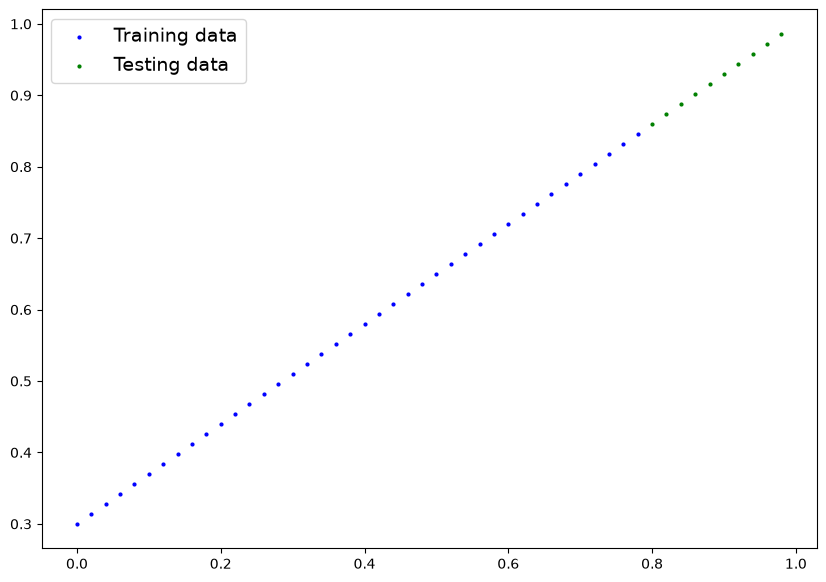

In [18]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
    
    """
    Plots training data, test data and compares predictions.
    """

    # Create a new figure with a specified size (10 inches wide and 7 inches tall)
    plt.figure(figsize=(10, 7))

    # Plot training data as blue dots (c colour ="b"), with a size of 4 (s=4), and label it as "Training data"
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

    # Plot test data as green dots (c colour ="g"), with a size of 4 (s=4), and label it as "Testing data"
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

    # Plot predictions if they exist
    if predictions is not None:
        # Plot predicitons as red dots (c colour ="r"), with a size of 4 (s=4), and label it as "Predictions"
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    # Add a legend to the plot, which will display the labels for each data series
    # The prop parameter is used to set the font size of the legend text to 14
    plt.legend(prop={"size": 14})

plot_predictions()

We want to build a model to try and learn the pattern of the blue dots (training), so if we fed our model the x values of the green dots (test) it would be able to predict the y values

# 38. Creating Our First PyTorch Model

We need to create a model that has a parameter for a and b in Y = a + bX

In our model it will be bias and weight respectively

In [ ]:
# Create linear regression model class
# A class is a blueprint for creating objects
# Class inherits from subclass nn.Module, which is the base class for all neural network modules in PyTorch
# To inherit means that the LinearRegressionModel class will have access to all the methods and properties of the nn.Module class without us writing it, allowing it to behave like a PyTorch model
# The nn.Module class provides a lot of functionality for building and training neural networks, such as automatic differentiation, parameter management, and model saving/loading
# Subclassing nn.Module allows us to define our own custom model architecture while still leveraging the built-in features of PyTorch
class LinearRegressionModel(nn.Module):

    # def __init__ is a special method in Python classes, known as the constructor. It is called when an instance (object) of the class is created. In this case, it initializes the LinearRegressionModel class, it sets up the objects starting state
    # self refers to the instance of the class being created. It allows us to access and set attributes (variables) and methods (functions) that belong to the class. In this case, it is used to define the weight parameter of the linear regression model.
    # since one class can produce many objects, self is how each method knows which object it is dealing with
    # e.g. self.weight means "this particular model's weight"
    # you never pass self in yourself, python does it automatically
    def __init__(self):

        # super() is a built-in function in Python that returns a temporary object of the superclass (parent class) that allows us to call its methods. In this case, it is used to call the __init__ method of the nn.Module class, which initializes the base class and sets up the necessary attributes for our custom model.
        # .__init__() is a method of the nn.Module class that initializes the base class. It is called using super() to ensure that the LinearRegressionModel class inherits all the functionality of the nn.Module class.
        super().__init__()


        # Inside the constructor we initialise model parameters to be used in various computations (could be different layers from torch.nn, single parameters, hard-coded values, or functions)
        # This line creates a learnable parameter called weight for the linear regression model. nn.Parameter is a special kind of tensor that is automatically registered as a parameter of the model, meaning it will be updated during training. The weight is initialized with a random value from a normal distribution (torch.randn(1)) and is set to require gradients (requires_grad=True), which means that PyTorch will compute gradients for this parameter after backpropagation through gradient descent (with torch.autograd), allowing it to be optimized during training.
        self.weight = nn.Parameter(torch.randn(1, 
                                               requires_grad=True, 
                                               dtype=torch.float))
    
        # This line creates a learnable parameter called bias for the linear regression model. Similar to the weight parameter, it is initialized with a random value from a normal distribution and is set to require gradients, allowing it to be optimized during training.
        self.bias = nn.Parameter(torch.randn(1,
                                            requires_grad=True, 
                                            dtype=torch.float))
        
    # Forward method to define the computation the model performs at every call
    # forward method needs to be defined if you are going to subclass nn.Module
    # "x" is the input data
    # forward needs to be indented the same as __init__
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Performs the forward pass of the linear regression model.
        The forward pass is where the input data is passed through the model to obtain predictions.
        In this case, it calculates the predicted output (y) using the linear equation y = weight * x + bias.
        """

        # This is the linear regression formula
        return self.weight * x + self.bias

Our model:
- Starts with random values (weight and bias)
- Looks at training data and updates those random numbers to better represent (or get closer to) the ideal values / pattern (the weight and bias values we used to create the data)
- If our model is learning correctly, it will take our weight and bias (or more accurately their gradients), run it through the forward calculation, then adjust the weight and bias (through gradient descent after backpropagation) to closer represent the known parameters

It does so through two main algorithms:
- Gradient descent
- Backpropagation

# 39. 

We created two parameters for the weight and bias we created

But for a dataset not created by us, we won't know the original parameters, so we won't define the new ones

Instead another module from nn will define the parameters for us, and define what they will end up being

# 40. Important Model Building Classes

torch.nn - contains all of the buildings for computational graphs (a neural network can be considered a computational graph)

torch.nn.Parameter - what parameters should our model try and learn, often a PyTorch layer from torch.nn will set these for us

torch.nn.Module - the base class for all neural networks, if you subclass it, you should overwrite forward()

torch.optim - this is where the optimisers in PyTorch live, they will help with gradient descent, optimiser algorithms optimise values to become ones that better represent the data

def forward() - All nn.Module subclasses require you to overwrite forward(), this method defines what happens in the forward computation

torch.utils.data.Dataset - Represents a map between key (label) and sample (features) pairs of your data, such as images and their associated labels

torch.utils.data.DataLoader - Creates a Python iterable over a torch Dataset (allows you to iterate over your data)

# 41. Internals Of Our Model

1. Get data ready (turn into tensors)
- torchvision.transforms
- torch.utils.data.Dataset
- torch.utils.data.Dataloader

2. Build or pick a pretrained model to suit your problem
- torch.nn
- torch.nn.Module
- torchvision.models

2.1. Pick a loss function and optimiser
- torch.optim

2.2 Build a training loop

3. Fit the model to the data and make a prediction

4. Evaluate the model
- torchmetrics

5. Improve through experimentation
- torch.utils.tensorboard

6. Save and reload your trained model

Checking the contents of our PyTorch

We can check out model parameters or what is inside our model using .parameters() 

In [20]:
# Create a random seed (because we created the parameters with random values)
# If we didn't create a random seed, we would get different values every time we ran torch.randn(n)

torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module)
model_0 = LinearRegressionModel()

# listing the parameters of model_0
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [21]:
# List named parameters
model_0.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

# 42. Making Predictions With Our Model

To check our model's predictive power, let's see how well it predicts y_test based on X_test

When we pass data through our model, it is going to run it through the forward method

An ideal model will predict the exact values of y_test

In [ ]:
# Make predictions with model

# with opens a resource and guarantees the resource will be closed when the with block completes, regardless of how it completes
# inference mode turns off gradient tracking, we are not doing training so we don't need to keep track of the gradient or how to update our model
# better version of torch.no_grad
with torch.inference_mode():

    # We pass our X_test data through our model
    y_preds = model_0(X_test)

y_preds


tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

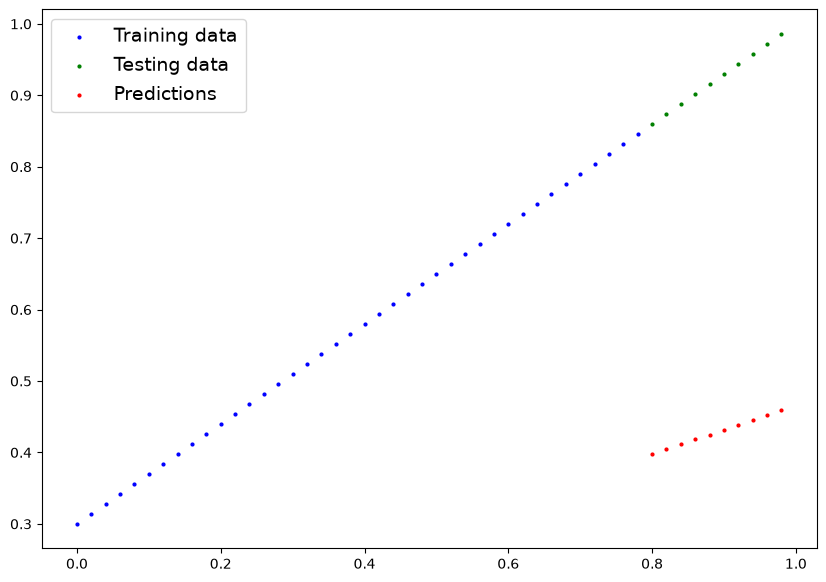

In [23]:
plot_predictions(predictions=y_preds)

# 43. Intuition of training a model with PyTorch

The idea of training is for a model to move from some unknown parameters (these may be random) to some known parameters
- From a poor representation of the data to a better representation of the data

One way to measure how poor or how wrong your models predictions are is to use a loss function

Loss function can be referred to as cost function or criterion in different areas

Loss function
- A function to measure how wrong your model's predictions are to the ideal output, lower is better

Optimiser
- Takes into account the loss of a model, and adjusts the model's parameters (e.g. weights and bias) to improve the loss function

Specifically for PyTorch we need:
- Training loop
- Testing loop

Mean absolute error (MAE)
- Take the difference between the ideal outputs and the model's predictions and find the mean
- nn.L1Loss in PyTorch

Mean squared error (MSE)
- Take the difference between the ideal outputs and the model's predictions, square each difference, sum them and find the mean
- nn.L2Loss

# 44. Setting up a loss function and optimiser

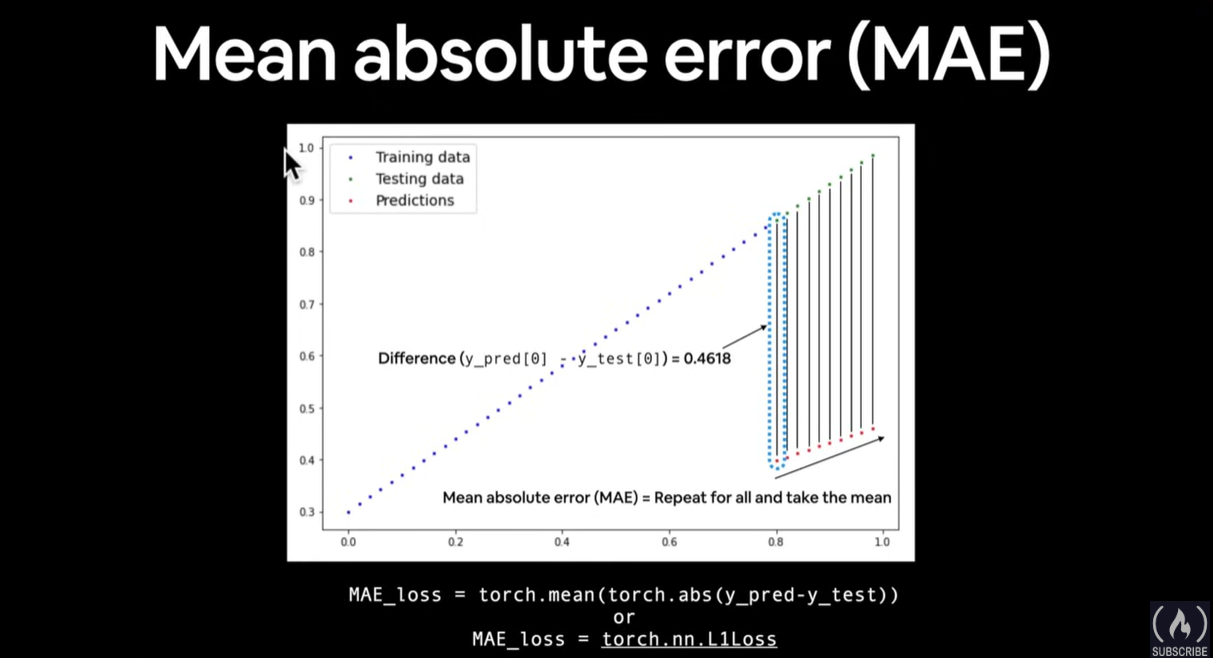

MAE_loss = torch.mean(torch.abs(y_pred-y_test))
or
MAE_loss = torch.nn.L1Loss

Our goal is to minimise the each difference between the ideal outputs and the models predictions, in turn leading to a decrease in the MAE

torch.optim
- A package implementing various optimisation algorithms
- Most commonly used methods are already supported (sgd, adam, etc...)
- Stochastic Gradient Descent (sgd) is the most popular, adam is a version of it
    - sgd is random gradient descent (stochastic means having a random probability distribution)
    - It starts by randomly adjusting the weights and bias
    - Once it finds some random values or random steps that have minimised the loss value, it continues adjusting them in that direction

In [ ]:
# Set up a loss function

loss_fn = nn.L1Loss()

# Set up an optimiser
# params=  tells you what parameters should the optimiser optimise
# lr = learning rate (higher lr means the more it adjusts each of the parameters in one go), very important hyperparameter (something you set yourself)
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01)

# 45. PyTorch Training Loop And Testing Loop Intuition

Some things we need in a training loop:
1. Loop through the data
2. Forward pass
    - This involves data moving through our model's forward() functions to make predicitons on data
    - Also called forward propagation
3. Calculate the loss
    - Compare forward pass predictions to ground truth labels
4. Loss backward
    - Move backwards through the network to calculate the gradients of each of the parameters of our model wrt the loss
    - Backpropagation
5. Optimiser step
    - Use the optimiser to adjust our model's parameter to try and improve the loss
    - Gradient descent

In [ ]:
# An epoch is one loop through the data
# Hyperparameter because we set it ourselves
epochs = 1

# 1. Loop through the data
for epoch in range(epochs):
    
    # Set the model to training mode (default)
    # train mode in PyTorch sets all parameters that require gradients to take gradients
    model_0.train()

    # turns off gradient tracking
    model_0.eval()